<a href="https://colab.research.google.com/github/JamesMungai254/Financial-Fraud-Analysis/blob/main/Financial_Fraud_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Financial Fraud Detection Analysis Report: Introduction

### Executive Summary
This report presents an in-depth exploratory data analysis (EDA) of a synthetic financial fraud dataset. The objective is to uncover patterns and anomalies associated with fraudulent transactions, thereby identifying critical features for effective fraud detection. The insights derived from this analysis will serve as a foundational step for developing and deploying robust machine learning models to combat financial fraud.

### Purpose and Scope
Financial fraud poses significant risks to individuals and institutions. This analysis aims to systematically investigate transaction data to distinguish legitimate activities from fraudulent ones. The scope includes a comprehensive examination of transaction attributes, user behavior indicators, and risk scores to build a clearer picture of fraud mechanisms within the dataset.

### Dataset Overview
The dataset includes simulated financial transactions, each characterized by `transaction_id`, `user_id`, `amount`, `transaction_type`, `merchant_category`, `country`, `hour` of transaction, and two synthetic risk indicators: `device_risk_score` and `ip_risk_score`. A crucial binary variable, `is_fraud`, labels each transaction as either fraudulent (1) or legitimate (0).

### Key Objectives of the Analysis
1.  **Descriptive Statistics and Data Distribution**: Understand the basic properties and distribution of all variables.
2.  **Fraudulent Transaction Characteristics**: Pinpoint unique traits, behaviors, and patterns prevalent in fraudulent transactions.
3.  **Feature Importance and Correlation**: Evaluate the relationships between different features and their correlation with the `is_fraud` target variable.
4.  **Data Quality and Preprocessing**: Identify and address any data quality issues, preparing the dataset for subsequent model development stages.

### Report Structure
This report is organized into the following sections:
*   **Data Loading and Initial Inspection**: Overview of the dataset and initial data quality checks.
*   **Exploratory Data Analysis (EDA)**: Detailed analysis of features, distributions, and relationships.
*   **Fraud Analysis**: Specific investigation into characteristics of fraudulent transactions.
*   **Feature Engineering**: Creation of new features to enhance model performance.
*   **Conclusion and Next Steps**: Summary of findings and recommendations for future work.

### Expected Outcomes
This analysis is expected to yield valuable insights into the dynamics of financial fraud, highlight the most predictive features, and guide the selection of appropriate methodologies for building fraud detection models. Ultimately, these findings will contribute to more effective fraud prevention and mitigation strategies.

In [ ]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("umitka/synthetic-financial-fraud-dataset")

# print("Path to dataset files:", path)

Using Colab cache for faster access to the 'synthetic-financial-fraud-dataset' dataset.
Path to dataset files: /kaggle/input/synthetic-financial-fraud-dataset


In [ ]:
# %mv /root/.cache/kagglehub/datasets/umitka/synthetic-financial-fraud-dataset/versions/1 /content


mv: cannot stat '/root/.cache/kagglehub/datasets/umitka/synthetic-financial-fraud-dataset/versions/1': No such file or directory


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("/content/1/synthetic_fraud_dataset.csv")
df.head()

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0


> Key features include:

* transaction_id: Unique identifier for each transaction

* user_id: Identifier for the user performing the transaction

* amount: Transaction amount (in local currency)

* transaction_type: Type of transaction (POS, Online, ATM, QR)

* merchant_category: Category of the merchant

* country: Country where the transaction took place

* hour: Hour of the transaction (0–23)

* device_risk_score and ip_risk_score: Risk indicators for the device and IP

* is_fraud: Label indicating if the transaction is fraudulent (1) or legitimate (0)

In [ ]:
df.shape # Number of rows and columns of the dataset

(10000, 10)

In [ ]:
df.describe() #statistical infor about the dataset

,transaction_id,user_id,amount,hour,device_risk_score,ip_risk_score,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,500.058700,178.142763,14.247100,0.183773,0.184669,0.050000
std,2886.89568,288.328495,531.647950,5.347383,0.177381,0.175772,0.217956
min,0.00000,0.000000,1.000000,0.000000,0.000030,0.000009,0.000000
25%,2499.75000,247.000000,65.084753,10.000000,0.075721,0.077762,0.000000
50%,4999.50000,503.000000,101.686510,14.000000,0.156583,0.158290,0.000000
75%,7499.25000,750.250000,138.280872,19.000000,0.234939,0.236968,0.000000
max,9999.00000,999.000000,11628.213881,23.000000,0.998737,0.999603,1.000000


In [ ]:
df.info() # Data type and the count of null values of the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   amount             10000 non-null  float64
 3   transaction_type   10000 non-null  object 
 4   merchant_category  10000 non-null  object 
 5   country            10000 non-null  object 
 6   hour               10000 non-null  int64  
 7   device_risk_score  10000 non-null  float64
 8   ip_risk_score      10000 non-null  float64
 9   is_fraud           10000 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


## Feature Engineering

performing feature encoding

In [ ]:
df.transaction_type.value_counts()

,count
transaction_type,
POS,2568
ATM,2529
QR,2506
Online,2397


In [ ]:
transactionCode = df.transaction_type.unique().tolist()
transactionCode.sort()
transactionCode

['ATM', 'Online', 'POS', 'QR']

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["transaction_type"] = le.fit_transform(df["transaction_type"])
df.transaction_type.value_counts()

,count
transaction_type,
2,2568
0,2529
3,2506
1,2397


In [ ]:
df.merchant_category.value_counts()

,count
merchant_category,
Food,2023
Travel,2015
Electronics,2007
Clothing,1982
Grocery,1973


In [ ]:
merchantCode = df.merchant_category.unique().tolist()
merchantCode.sort()
merchantCode

['Clothing', 'Electronics', 'Food', 'Grocery', 'Travel']

In [ ]:
df.merchant_category = le.fit_transform(df.merchant_category)
df.merchant_category.value_counts()

,count
merchant_category,
2,2023
4,2015
1,2007
0,1982
3,1973


In [ ]:
df.country.value_counts()

,count
country,
US,2050
FR,2027
UK,1965
DE,1930
TR,1928
NG,100


In [ ]:
countryOrg = df.country.unique().tolist()
countryOrg.sort()
countryOrg

['DE', 'FR', 'NG', 'TR', 'UK', 'US']

In [ ]:
countryOrg

['DE', 'FR', 'NG', 'TR', 'UK', 'US']

In [ ]:
df.country = le.fit_transform(df.country)
df.country.value_counts()

,count
country,
5,2050
1,2027
4,1965
0,1930
3,1928
2,100


## EDA

In [ ]:
dfHue = df.drop(["transaction_id", "user_id"], axis=1)

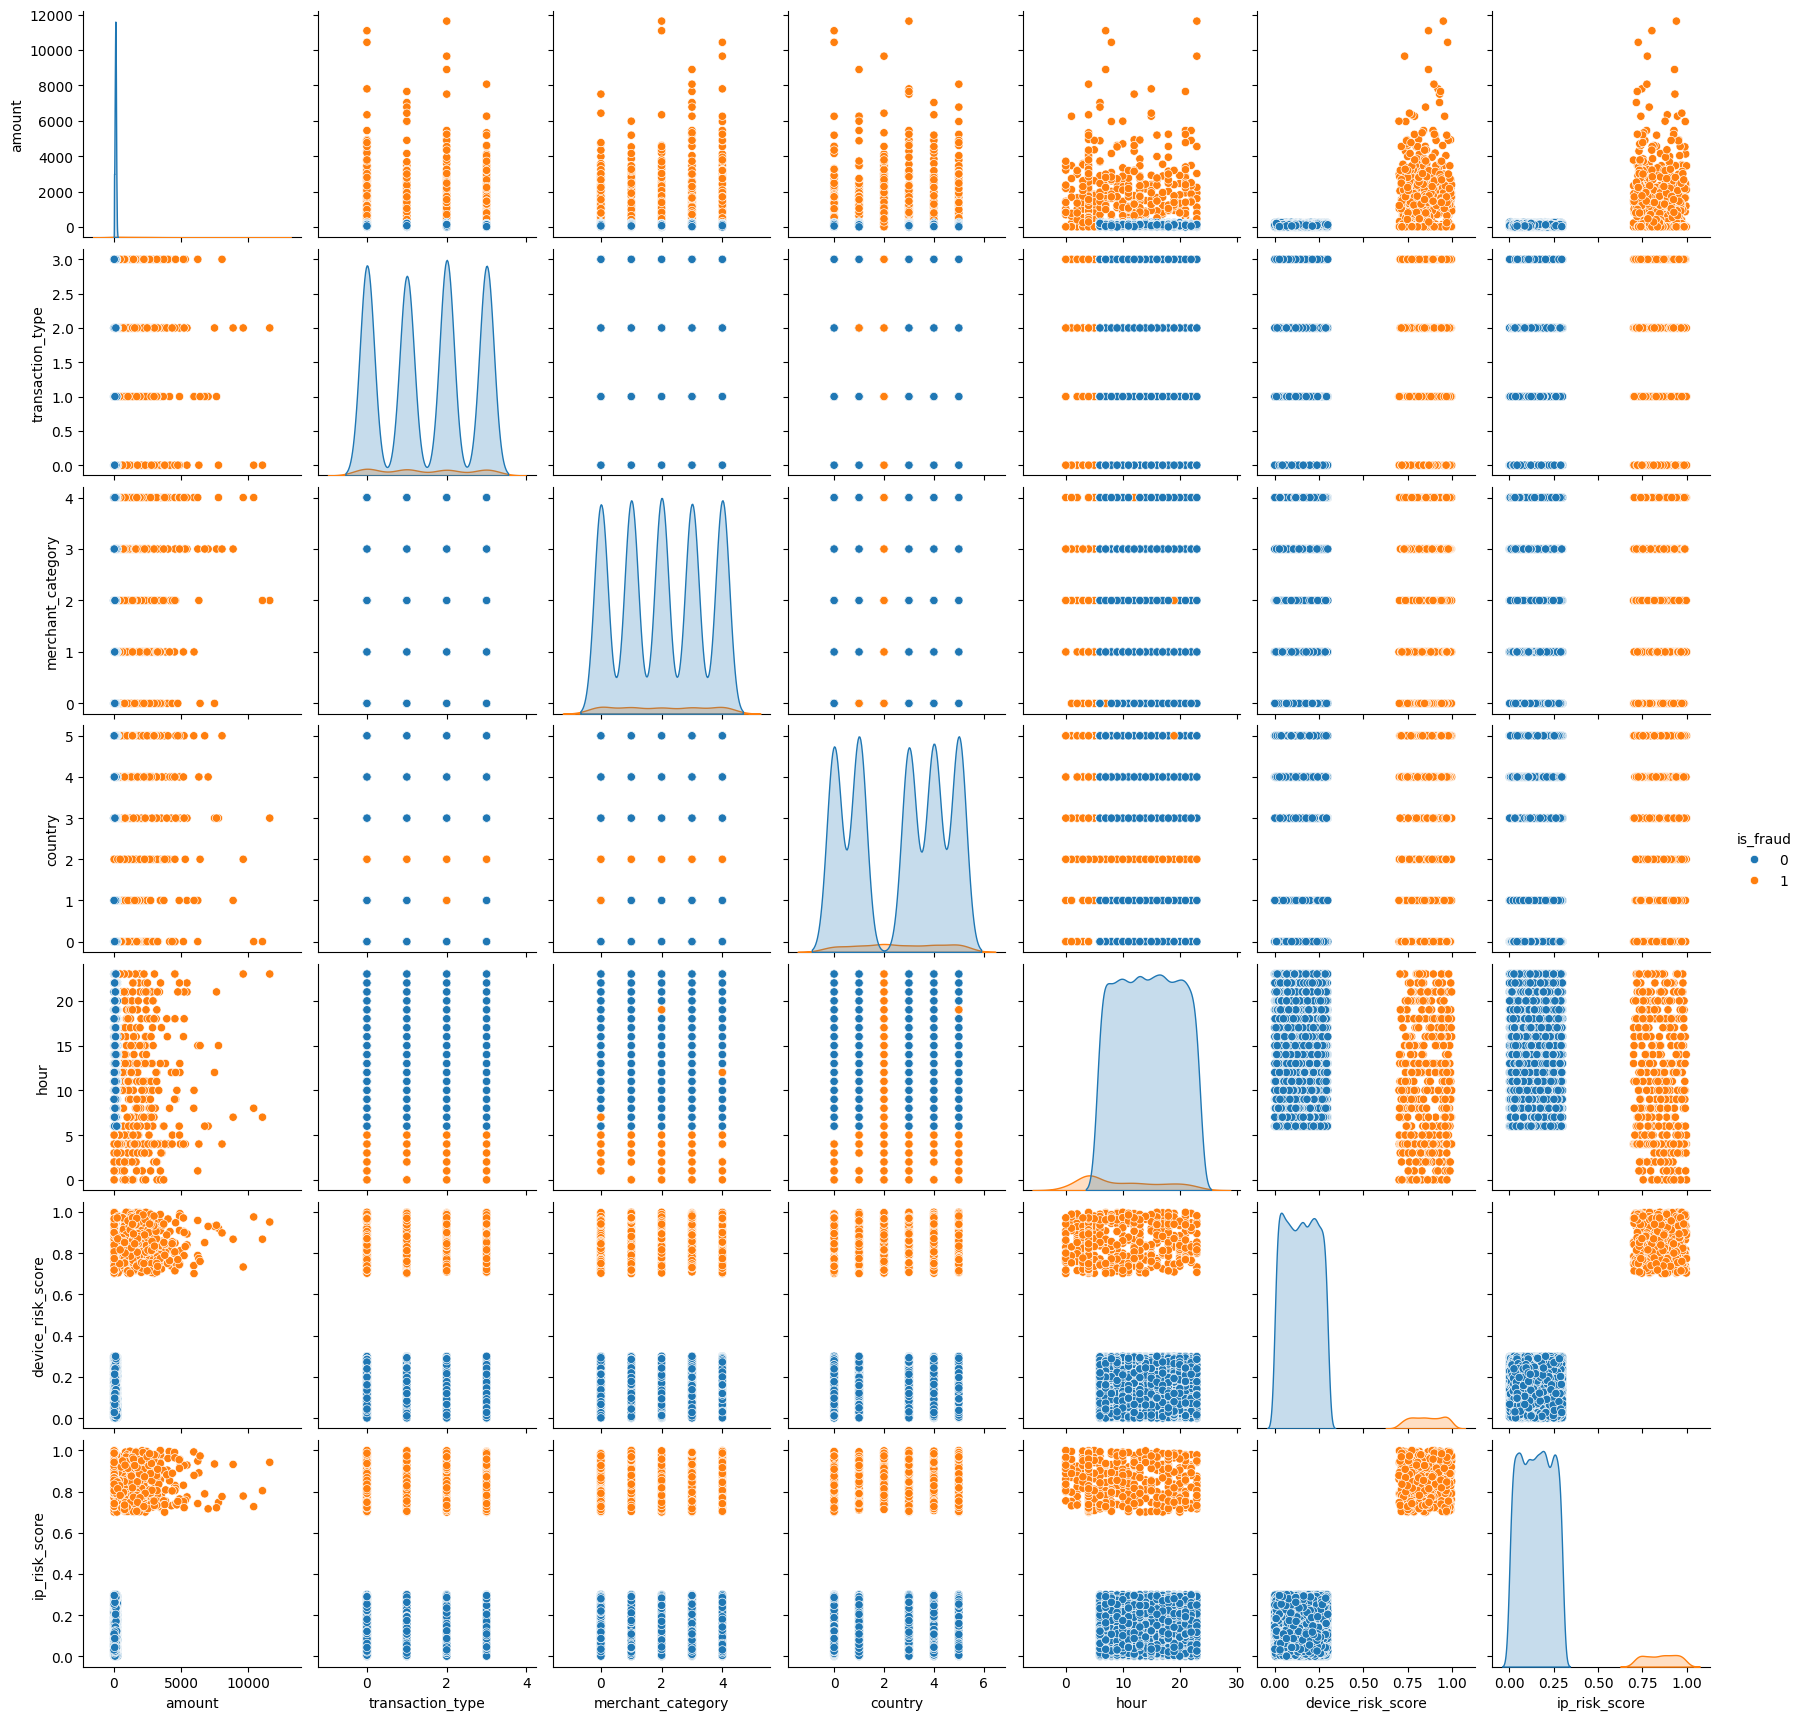

In [ ]:
sns.pairplot(dfHue, hue="is_fraud")
plt.show()

In [ ]:
import plotly.express as px

correlation_matrix = dfHue.corr() * 100

fig = px.imshow(correlation_matrix,
                text_auto=True,
                aspect="auto",
                color_continuous_scale="RdBu_r",
                title='Interactive Percentage Correlation Matrix',
                labels=dict(x="Features", y="Features", color="Correlation (%)"))

fig.update_layout(xaxis_nticks=len(correlation_matrix.columns),
                  yaxis_nticks=len(correlation_matrix.index),
                  xaxis_showgrid=False,
                  yaxis_showgrid=False)

fig.show()

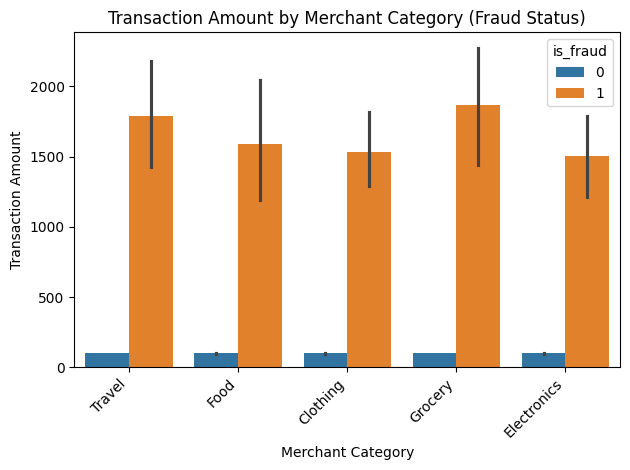

In [ ]:
original_merchant_category_encoder = LabelEncoder()
original_merchant_category_encoder.fit(merchantCode) #
df['original_merchant_category'] = original_merchant_category_encoder.inverse_transform(df['merchant_category'])
sns.barplot(x="original_merchant_category", y="amount", data=df, hue="is_fraud")
plt.title("Transaction Amount by Merchant Category (Fraud Status)")
plt.xlabel("Merchant Category")
plt.ylabel("Transaction Amount")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

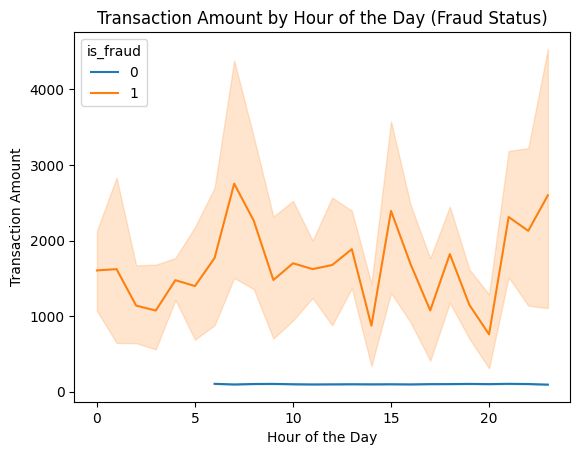

In [ ]:
sns.lineplot(x="hour", y="amount", data=df, hue="is_fraud")
plt.title("Transaction Amount by Hour of the Day (Fraud Status)")
plt.xlabel("Hour of the Day")
plt.ylabel("Transaction Amount")
plt.show()

In [ ]:
countryEncoded = LabelEncoder()
countryEncoded.fit(countryOrg)
df["Orgcountry"] = countryEncoded.inverse_transform(df["country"])


fig = px.box(
    df,
    x="Orgcountry",
    y="amount",
    color="is_fraud",
    title="Transaction Amount by Fraud Status")
fig.update_layout(xaxis_title="Fraud Status", yaxis_title="Transaction Amount")
fig.show()

In [ ]:
fig = px.box(
    df,
    x="is_fraud",
    y="amount",
    color="is_fraud",
    title="Transaction Amount by Fraud Status")
fig.update_layout(xaxis_title="Fraud Status", yaxis_title="Transaction Amount")
fig.show()